In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Results = pd.read_excel('Results-DISTINCT.xlsx')
Results = Results.drop('Unnamed: 0',axis=1)
print(Results.shape)
print(len(Results['Model Name'].unique()))
Results.head(3)

(5000, 14)
22


,Model Name,feature_selection,R2,MAE,MSE,MAPE,MedianAE,MaxE,MMRE,PRED(25),fold,k,features,Model Name & Sel & Tune
0,DummyRegressor(),Best,-0.050270,21.000000,489.163111,1.004637,16.161290,31.838710,1.004637,0.000,0,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat...",DummyRegressor()Best
1,DummyRegressor(),Best,-2.048392,23.500000,610.250000,1.296458,22.500000,37.000000,1.296458,0.125,1,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat...",DummyRegressor()Best
2,DummyRegressor(),Best,-0.000452,42.415323,3706.784729,1.578408,28.580645,157.419355,1.578408,0.000,2,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat...",DummyRegressor()Best


In [3]:
Results.groupby('Model Name').agg({'Model Name':'count'})

,Model Name
Model Name,
ARDRegression(),300
BayesianRidge(),300
DecisionTreeRegressor(),300
DummyRegressor(),100
DummyRegressor(strategy='median'),100
ElasticNet(),300
GradientBoostingRegressor(),300
HuberRegressor(),200
KNeighborsRegressor(),200


In [4]:
Results['feature_selection'].value_counts()

feature_selection
Best      2200
RFESel    1400
GridCV    1400
Name: count, dtype: int64

In [5]:
Results.loc[Results['feature_selection']=='GridCV','Model Name'].unique()

array(['Ridge()', 'Lasso()', 'ElasticNet()', 'LassoLars()',
       'ARDRegression()', 'BayesianRidge()', 'TweedieRegressor()',
       'RANSACRegressor(min_samples=5)', 'HuberRegressor()',
       'QuantileRegressor()', 'DecisionTreeRegressor()',
       'KNeighborsRegressor()', 'RandomForestRegressor()',
       'GradientBoostingRegressor()'], dtype=object)

In [6]:
Models_wo_GridSearch = set(Results['Model Name'].unique()) - set(Results.loc[Results['feature_selection']=='GridCV','Model Name'].unique())
Models_wo_GridSearch

{'DummyRegressor()',
 "DummyRegressor(strategy='median')",
 'Lars()',
 'LinearRegression()',
 'MLPRegressor()',
 'OrthogonalMatchingPursuit()',
 'SVR()',
 'TheilSenRegressor()'}

In [7]:
Models_w_RFESel = set(Results.loc[Results['feature_selection']=='RFESel','Model Name'].unique())
Models_w_RFESel

{'ARDRegression()',
 'BayesianRidge()',
 'DecisionTreeRegressor()',
 'ElasticNet()',
 'GradientBoostingRegressor()',
 'Lasso()',
 'LassoLars()',
 'LinearRegression()',
 'OrthogonalMatchingPursuit()',
 'QuantileRegressor()',
 'RandomForestRegressor()',
 'Ridge()',
 'TheilSenRegressor()',
 'TweedieRegressor()'}

In [8]:
Models_wo_GridSearch_w_RFE_Sel = Models_wo_GridSearch & Models_w_RFESel
Models_wo_GridSearch_w_RFE_Sel 

{'LinearRegression()', 'OrthogonalMatchingPursuit()', 'TheilSenRegressor()'}

In [9]:
Models_wo_GridSearch_wo_RFE_Sel = Models_wo_GridSearch - Models_w_RFESel
Models_wo_GridSearch_wo_RFE_Sel

{'DummyRegressor()',
 "DummyRegressor(strategy='median')",
 'Lars()',
 'MLPRegressor()',
 'SVR()'}

In [10]:
df_temp1 = Results.loc[(Results['Model Name'].isin(Models_wo_GridSearch_w_RFE_Sel)) & (Results['feature_selection']=='RFESel'),:].copy()
df_temp1['feature_selection'] = 'assumed'
df_temp1.shape

(300, 14)

In [11]:
df_temp2 = Results.loc[(Results['Model Name'].isin(Models_wo_GridSearch_wo_RFE_Sel)) & (Results['feature_selection']=='Best'),:].copy()
df_temp2['feature_selection'] = 'assumed'
df_temp2.shape

(500, 14)

In [12]:
Results = pd.concat([Results,df_temp1,df_temp2])
Results.shape

(5800, 14)

In [13]:
Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:].shape

(2200, 14)

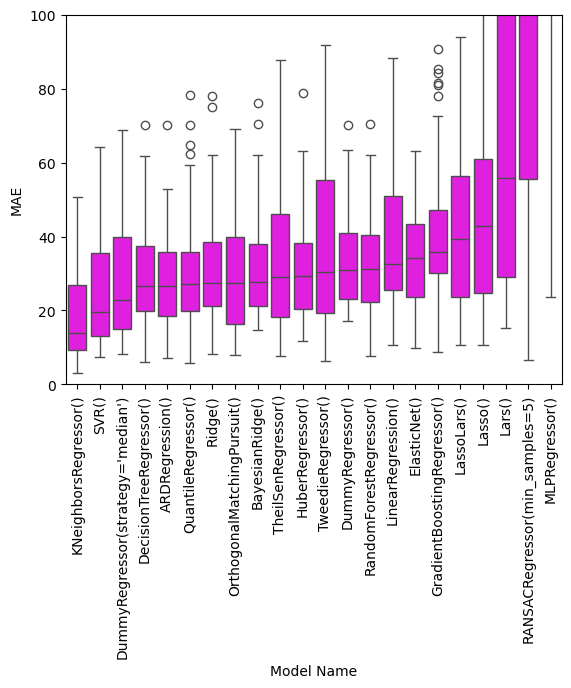

In [14]:
df_median = Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:].groupby('Model Name').agg({'MAE': 'median'}).sort_values('MAE').reset_index().reset_index()
df_median = df_median.rename(columns={'index':'rank'})
ResultsMAE = pd.merge(Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:],df_median[['rank','Model Name']],on='Model Name')
ResultsMAE = ResultsMAE.sort_values('rank')
ax = sns.boxplot(x=ResultsMAE["Model Name"], y=ResultsMAE["MAE"], native_scale=True, color='magenta')
ax.set_ylim(0,100)
ax.tick_params(axis='x', rotation=90)
fig = ax.get_figure()
fig.figsize=(10,8)
fig.savefig("MAE_BoxPlot.png",bbox_inches='tight')

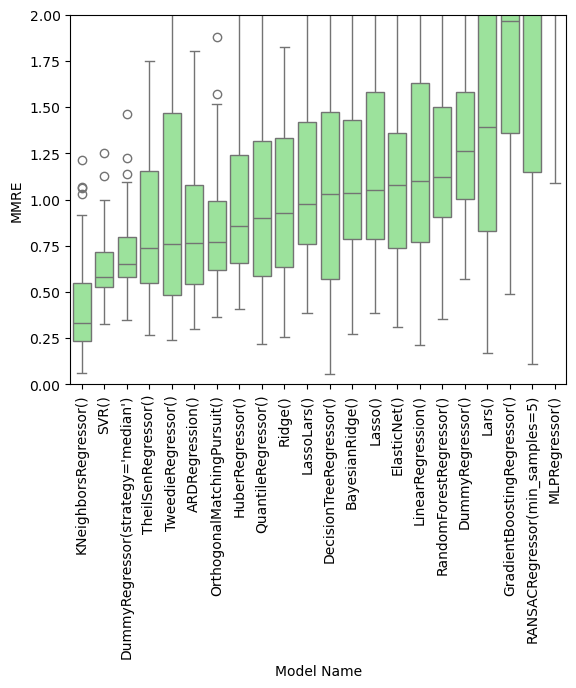

In [15]:
df_median = Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:].groupby('Model Name').agg({'MMRE': 'median'}).sort_values('MMRE').reset_index().reset_index()
df_median = df_median.rename(columns={'index':'rank'})
ResultsMMRE = pd.merge(Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:],df_median[['rank','Model Name']],on='Model Name')
ResultsMMRE = ResultsMMRE.sort_values('rank')
ax = sns.boxplot(x=ResultsMMRE["Model Name"], y=ResultsMMRE["MMRE"], native_scale=True, color='lightgreen')
ax.set_ylim(0,2)
ax.tick_params(axis='x', rotation=90)
fig = ax.get_figure()
fig.figsize=(10,8)
fig.savefig("MMRE_BoxPlot.png",bbox_inches='tight')

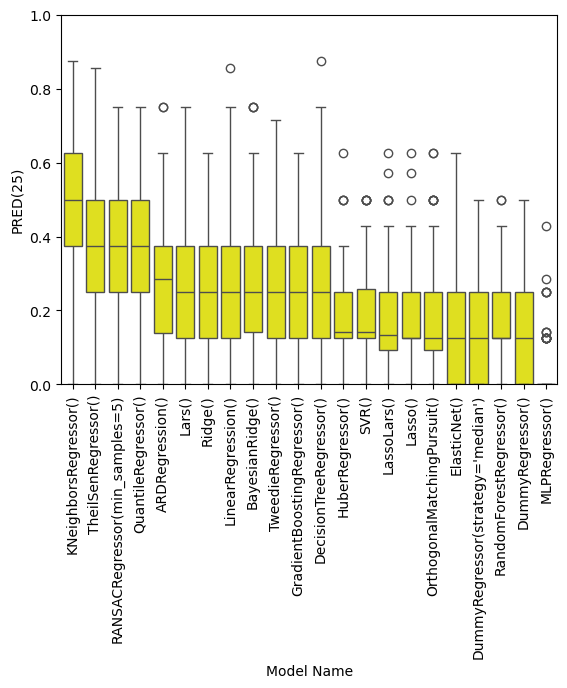

In [16]:
df_median = Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:].groupby('Model Name').agg({'PRED(25)': 'median'}).sort_values('PRED(25)',ascending=False).reset_index().reset_index()
df_median = df_median.rename(columns={'index':'rank'})
ResultsPRED25 = pd.merge(Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:],df_median[['rank','Model Name']],on='Model Name')
ResultsPRED25 = ResultsPRED25.sort_values('rank')
ax = sns.boxplot(x=ResultsPRED25["Model Name"], y=ResultsPRED25["PRED(25)"], native_scale=True, color='yellow')
ax.set_ylim(0,1)
ax.tick_params(axis='x', rotation=90)
fig = ax.get_figure()
fig.figsize=(10,8)
fig.savefig("PRED25_BoxPlot.png",bbox_inches='tight')

In [17]:
ResultsKNN = Results.loc[(Results['Model Name']=='KNeighborsRegressor()') & (Results['feature_selection']=='GridCV'),:]
print(ResultsKNN.shape)
ResultsKNN.to_excel('KNN_Results_Grid.xlsx')

(100, 14)


In [18]:
ResultsKNN = Results.loc[(Results['Model Name']=='KNeighborsRegressor()') & (Results['feature_selection']=='Best'),:]
print(ResultsKNN.shape)
ResultsKNN.to_excel('KNN_Results_Best.xlsx')

(100, 14)


In [19]:
tmp = Results.loc[Results['feature_selection'].isin(['GridCV','assumed']),:].groupby('Model Name').agg({'MAE': ['mean','median'], 
                                                                                                            'MMRE': ['mean','median'],
                                                                                                            'PRED(25)': ['mean','median']
                                                                                                          })
tmp.to_excel('Results_summary.xlsx')